# Phase 1: Data Understanding

The initial step is to load the dataset and investigate its structure. We want to understand the features, inspect missing values, and obtain initial descriptive statistics. 

In [1]:
# Phase 1: Data Understanding
# We start by importing the necessary tools (libraries) for our project.
# pandas: for handling data tables (like Excel)
# numpy: for numerical calculations
# matplotlib & seaborn: for creating beautiful graphs and charts
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display settings so we can see all columns without them getting cut off
pd.set_option('display.max_columns', None)
# Set a clean white grid theme for our charts so they are easy to read
sns.set_theme(style="whitegrid")

# Load our raw wholesale customer dataset from the CSV file into a pandas 'DataFrame' (table)
df = pd.read_csv('Wholesale customers data.csv')

# Display the first 5 rows of our data to get a quick visual feel for what it looks like
display(df.head())

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


### Basic Information
Let's check the data types and if there are any null values.

In [2]:
# Check the basic information about our dataset
# This tells us how many rows/columns we have, and what type of data is in each column (e.g., numbers vs text)
# It's an essential first step to ensure our data loaded correctly.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [3]:
# Check for missing data (null values)
# Machine learning models cannot handle missing information. 
# We need to know if any cells are empty so we can decide whether to fill them in or delete the row.
print("Missing values in each column:")
display(df.isnull().sum())

Missing values in each column:


Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

### Descriptive Statistics
Here we observe the distributions explicitly. Notice the substantial differences between median (50%) and the maximum value across continuous categories.

In [4]:
# Generate a statistical summary of our numerical data
# This gives us the average (mean), the middle point (median/50%), the smallest (min), and largest (max) values.
# Why? We look here to spot initial signs of 'outliers' (values that are unusually huge compared to the rest).
display(df.describe())

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


### Visualizing Data Disruptions (Skewness & Outliers)
While earlier we used `df.describe()` to mathematically identify variations, providing a visual representation paints a much clearer picture for clients. Below, we've produced two key visualization types:
1. **Histograms (with Mean and Median lines)**: This shows the distribution shape. We can clearly see the distribution is heavily pulled to the right, signifying 'Positive Skewness'. The 'Mean' is heavily disrupted upwards by massive spenders, abandoning the 'Median'. 
2. **Boxplots**: A standard approach to find outliers. The solid boxes represent where the central 50% of our clients lie. The dots scattered high above are our 'disruptions'—individual clients purchasing massively larger quantities than a normal customer.

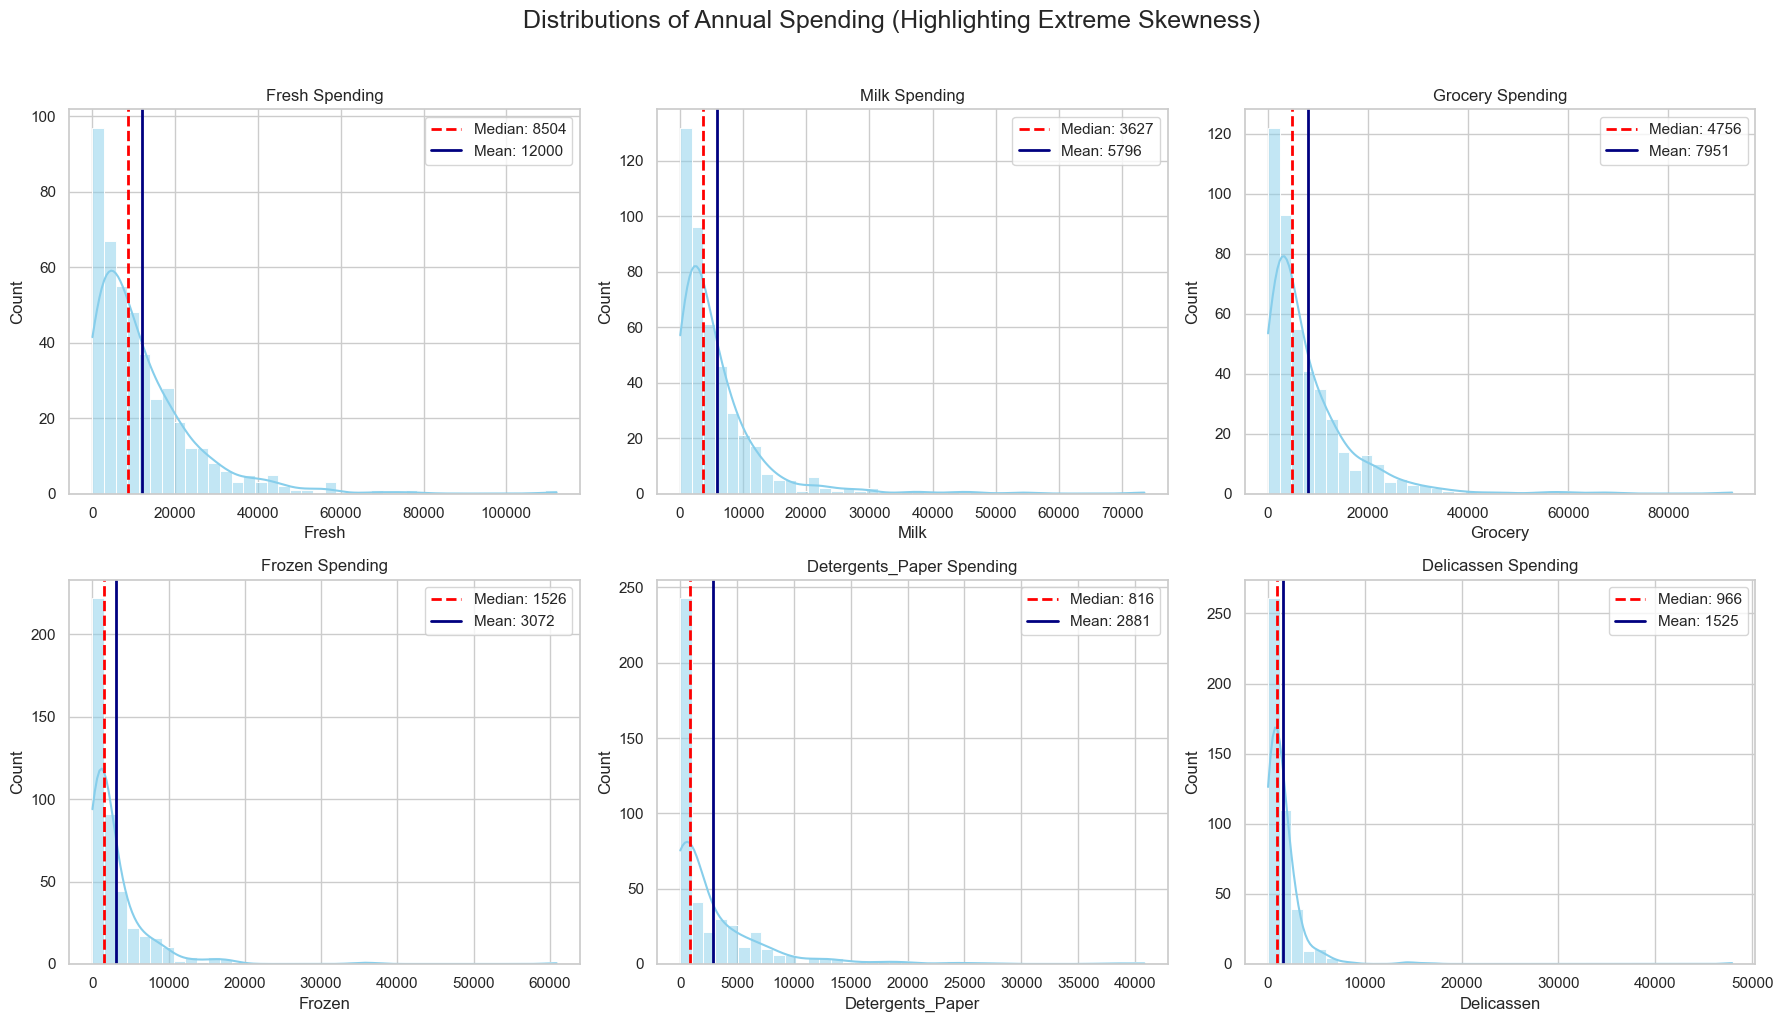

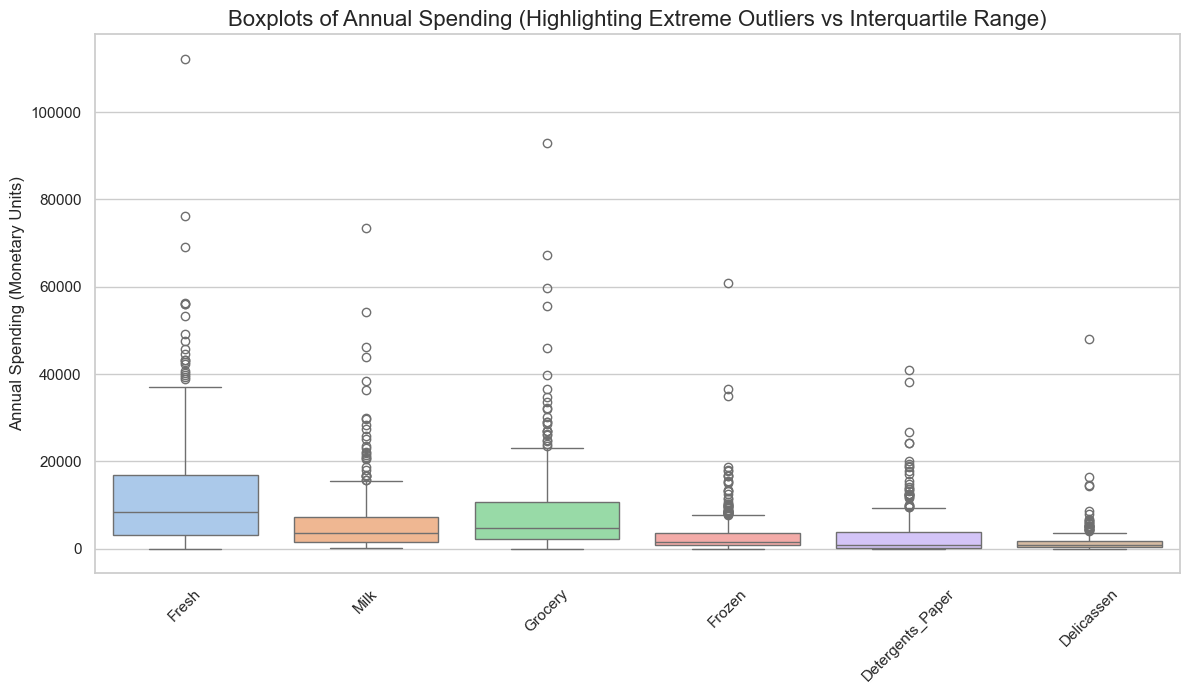

In [5]:
import warnings
# Ignore harmless warning messages to keep our output clean
warnings.filterwarnings('ignore')

# List of the product categories we want to analyze
continuous_features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

# --- Step 1: Create Histograms to see the shape of the data ---
# We create a grid of charts (2 rows, 3 columns)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
fig.suptitle('Distributions of Annual Spending (Highlighting Extreme Skewness)', fontsize=18, y=1.02)
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    # Plot the histogram (bar chart showing frequency) with a smooth curve (kde=True)
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue', bins=40)
    
    # Calculate the median (the dead center of the data) and mean (the mathematical average)
    median_val = df[col].median()
    mean_val = df[col].mean()
    
    # Draw lines for the median and mean to visually show how far apart they are
    # When the mean is pulled far to the right of the median, it proves our data is "Right-Skewed" by giant outliers
    axes[i].axvline(median_val, color='red', linestyle='--', linewidth=2, label=f'Median: {median_val:.0f}')
    axes[i].axvline(mean_val, color='navy', linestyle='-', linewidth=2, label=f'Mean: {mean_val:.0f}')
    axes[i].set_title(f'{col} Spending')
    axes[i].legend()

# Neatly arrange and show the plots
plt.tight_layout()
plt.show()

# --- Step 2: Create Boxplots to clearly highlight outliers ---
# A boxplot shows the middle 50% of customers inside the 'box'. 
# Any dots way above the box are our 'outliers' or 'whales'—customers buying massive amounts.
plt.figure(figsize=(14, 7))
sns.boxplot(data=df[continuous_features], palette='pastel')
plt.title('Boxplots of Annual Spending (Highlighting Extreme Outliers vs Interquartile Range)', fontsize=16)
plt.ylabel('Annual Spending (Monetary Units)')
plt.xticks(rotation=45)
plt.show()

# Phase 2: Data Cleaning & Preprocessing
Our goals in this phase are to eliminate any basic flaws (like full-row duplicates), and aggressively tackle the extreme positive skew present in our spending data via Log Transformation and Standard Scaling. We will then save the cleaned result to a dedicated `data/` folder.

In [6]:
# Phase 2: Data Cleaning and Preprocessing

# Check how many rows we have before cleaning
print(f"Original shape: {df.shape}")

# Remove duplicate rows. If a customer was accidentally entered twice, it could confuse the model.
df = df.drop_duplicates()
print(f"Shape after duplicates removed: {df.shape}")

from sklearn.preprocessing import StandardScaler
import numpy as np
import os

spend_features = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

# --- Log Transformation ---
# Why? Our data has extreme "whales" (massive spenders) that squish all the normal customers together in the model's eyes.
# A Logarithmic (Log) Transform mathematically shrinks these giant numbers down, creating a more balanced "bell curve".
# We use np.log1p instead of np.log because log(0) causes a crash, whereas log1p safely handles zeros.
log_data = np.log1p(df[spend_features])

# --- Standard Scaling ---
# Why? 'Fresh' food spending might be naturally much higher numbers (e.g., $100,000) than 'Delicatessen' ($1,000).
# Standard Scaling puts all categories on the exact same level playing field (so average = 0, standard deviation = 1).
# This prevents high-dollar categories from bullying the smaller categories when the model calculates distances.
scaler = StandardScaler()
scaled_data = scaler.fit_transform(log_data)

# Put the cleaned, scaled data back into a readable table format
df_scaled = pd.DataFrame(scaled_data, columns=spend_features, index=df.index)

# Re-attach the 'Channel' (Hotel/Retail) and 'Region' columns that we ignored during scaling
df_cleaned = df[['Channel', 'Region']].join(df_scaled)

# Ensure our 'data' folder exists, then save the cleaned data so we don't have to redo this step next time!
os.makedirs('data', exist_ok=True)
df_cleaned.to_csv('data/Cleaned_Wholesale_Data.csv', index=False)
print("Cleaned & Scaled data saved to 'data/Cleaned_Wholesale_Data.csv'!")

# Show the cleaned data. Notice the numbers look completely different (they are now scaled)!
display(df_cleaned.head())

Original shape: (440, 8)
Shape after duplicates removed: (440, 8)
Cleaned & Scaled data saved to 'data/Cleaned_Wholesale_Data.csv'!


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,0.486184,0.976299,0.440155,-1.509250,0.644143,0.408966
1,2,3,0.087889,0.990956,0.652171,0.134052,0.766043,0.627926
2,2,3,0.016356,0.891151,0.454687,0.376899,0.804405,1.776833
3,1,3,0.517477,-0.957973,-0.084792,1.141574,-0.328712,0.633133
4,2,3,0.880631,0.439662,0.395847,0.757322,0.404939,1.456588


# Phase 3: Exploratory Data Analysis
We will visualize the transformed distributions to ensure they are more normalized, and map out the correlations between different categorical spends.

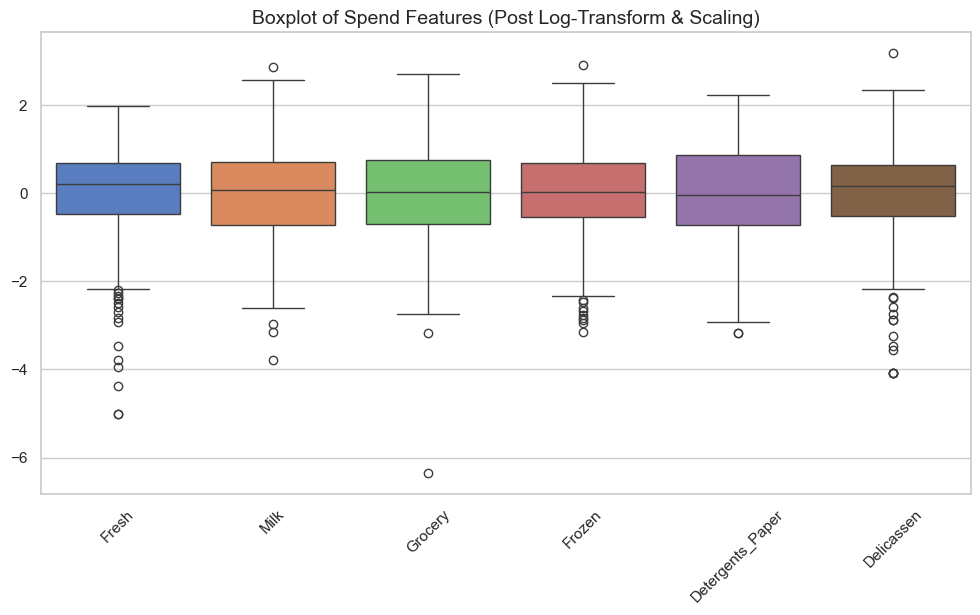

In [7]:
# Phase 3: Exploratory Data Analysis (EDA) on Cleaned Data

# Let's look at the boxplots again, but this time on our freshly transformed and scaled data.
# Why? We want to prove that the 'Log Transform' and 'Standard Scaler' actually worked.
# You will see the extreme outliers have been pulled in significantly, and the boxes are all evenly sized around zero.
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_cleaned[spend_features], palette='muted')
plt.title("Boxplot of Spend Features (Post Log-Transform & Scaling)", fontsize=14)
plt.xticks(rotation=45)
plt.show()

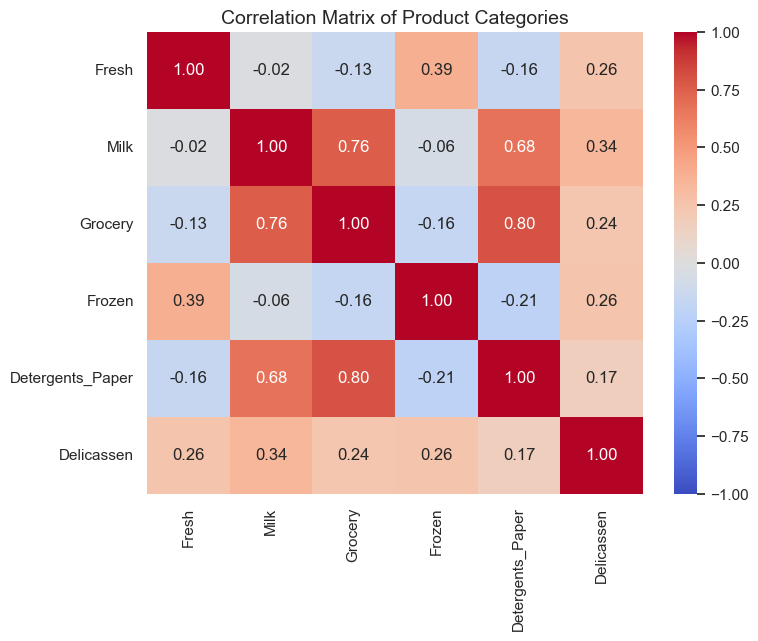

In [8]:
# Correlation Matrix Heatmap
# Why? This map tells us if spending in one category is linked to spending in another.
# A score near 1 (red) means a strong positive connection (e.g., if they buy a lot of Grocery, they also buy a lot of Detergent).
# A score near 0 means no connection.
plt.figure(figsize=(8, 6))
sns.heatmap(df_cleaned[spend_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Product Categories", fontsize=14)
plt.show()

# Phase 4: Clustering & Customer Segmentation
Using K-Means clustering to dynamically segment customers based on their spending behavior. We will use the Elbow Method and Silhouette Score to find the mathematical 'best' number of clusters ($K$).

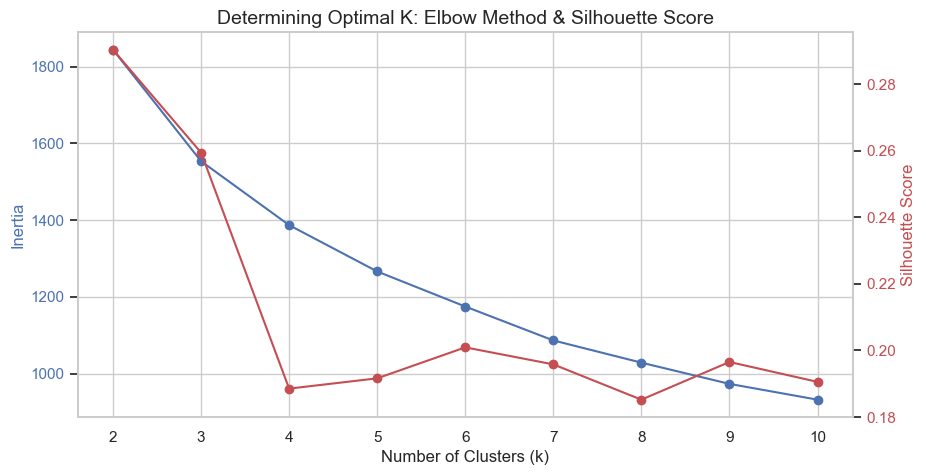

In [9]:
# Phase 4: Clustering (Customer Segmentation)
# We are using K-Means, which tries to group customers into 'K' number of segments based on their spending.
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore') # ignore harmless K-means warnings

# We don't know how many buyer personas (clusters) exist yet.
# So, we will test grouping them into anywhere from 2 to 10 clusters (K_range).
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    # Build a K-Means model for the current 'K'
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    # Fit the model to our scaled data and immediately predict which cluster each customer belongs to
    clusters = kmeans.fit_predict(df_scaled)
    
    # Measure 1: Inertia (How tightly packed the clusters are. Lower is better, but it naturally drops as K goes up).
    inertia.append(kmeans.inertia_)
    
    # Measure 2: Silhouette Score (How distinct the clusters are from each other. Closer to 1 is better).
    silhouette_scores.append(silhouette_score(df_scaled, clusters))

# --- Plot the Results ---
# We plot both metrics on the same graph to find the "sweet spot"
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Inertia on the left Y-axis. We are looking for an "Elbow" (where the drop suddenly flattens out).
ax1.plot(K_range, inertia, 'bo-', label='Inertia (Within-Cluster Sum of Squares)')
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia', color='b', fontsize=12)
ax1.tick_params(axis='y', labelcolor='b')

# Plot Silhouette Score on the right Y-axis. We are looking for peaks (high points).
ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_scores, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r', fontsize=12)
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Determining Optimal K: Elbow Method & Silhouette Score', fontsize=14)
plt.grid(False)
plt.show()

Based on the Silhouette score hitting a peak and the inertia showing an 'elbow', `k=3` or `k=5` are great candidates. We will proceed with **K=3** for interpretability.

In [10]:
# Based on the graphs above, creating 3 clusters gives us a great balance of tight, distinct groups.
optimal_k = 3

# Train the final K-Means model using exactly 3 clusters
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Assign the predicted cluster number (0, 1, or 2) back to our original raw dataframe 
# so we can easily interpret the business meaning later.
df['Cluster'] = final_kmeans.fit_predict(df_scaled)

print("--- CLUSTER CHARACTERISTICS ---")
# To understand WHO is in each cluster, we calculate the average spending for each category per cluster.
# This reveals our "Buyer Personas" (e.g., the 'Fresh Food lovers' vs the 'Grocery giants').
target_insight = df.groupby('Cluster')[spend_features].mean().round(2)
display(target_insight)

--- CLUSTER CHARACTERISTICS ---


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,2898.58,7135.94,12569.71,606.55,5554.39,782.86
1,17042.84,10559.67,13333.60,4133.10,4987.02,2846.59
2,11938.72,2005.69,2502.09,3265.54,424.48,891.38


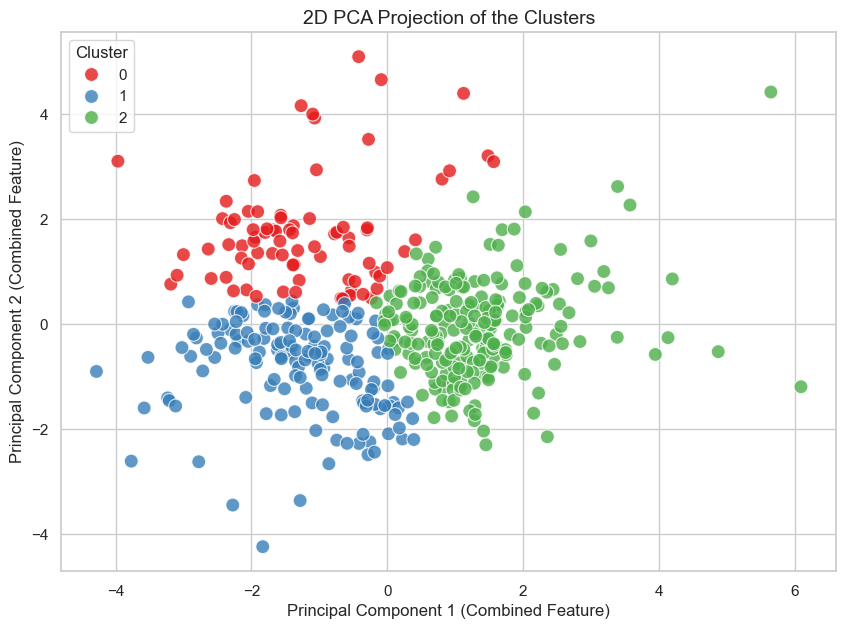

In [11]:
# PCA (Principal Component Analysis) Visual Validation
# Why? Our data has 6 dimensions (Fresh, Milk, Grocery, etc.), making it physically impossible to graph on a 2D screen.
# PCA is a math trick that smashes all 6 dimensions down into 2 dimensions while keeping as much of the original "shape" as possible.
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced_data = pca.fit_transform(df_scaled)

# Now we plot the 2D version of our customers and color them by their assigned K-Means cluster.
# If the colors are mostly grouped together, our clustering worked well!
plt.figure(figsize=(10, 7))
sns.scatterplot(x=reduced_data[:,0], y=reduced_data[:,1], hue=df['Cluster'], palette='Set1', s=100, alpha=0.8)
plt.title('2D PCA Projection of the Clusters', fontsize=14)
plt.xlabel('Principal Component 1 (Combined Feature)')
plt.ylabel('Principal Component 2 (Combined Feature)')
plt.legend(title='Cluster')
plt.show()

### Model 2: Hierarchical Clustering (Agglomerative)
We will use Agglomerative Clustering and visualize the dendrogram to understand the hierarchical relationships.


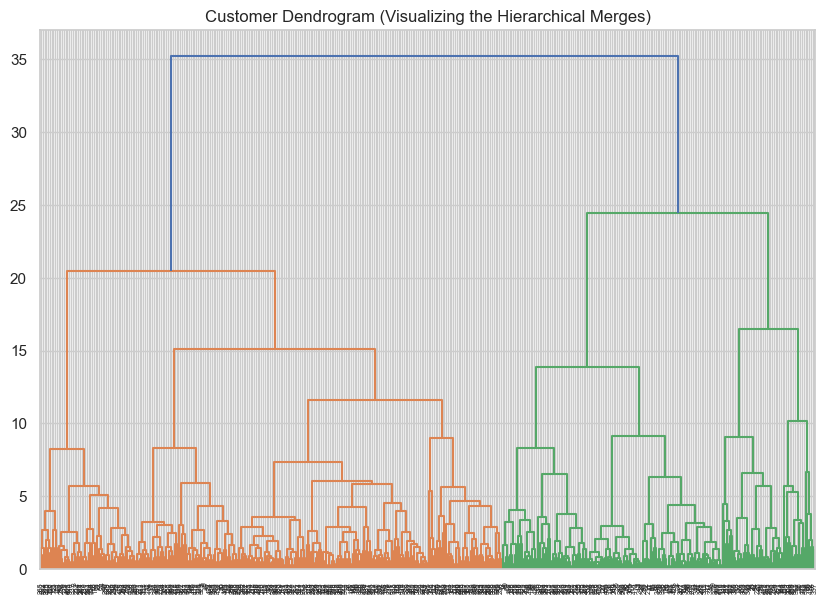

In [12]:
# Model 2: Hierarchical Clustering (Agglomerative)
# How it works: Instead of guessing K upfront, this algorithm starts by treating every customer as their own cluster.
# It then slowly merges the most similar customers together step-by-step until everyone is joined in one giant tree.
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as shc
import matplotlib.pyplot as plt

# The 'Dendrogram' is a visual representation of that merging process tree.
# By looking at the longest vertical lines before a split, we can visually see how many natural segments exist.
plt.figure(figsize=(10, 7))
plt.title("Customer Dendrogram (Visualizing the Hierarchical Merges)")
# 'Ward' method minimizes the variance between merged clusters (keeps them tight)
dend = shc.dendrogram(shc.linkage(df_scaled, method='ward'))
plt.show()

# Based on our K-Means success, we tell this model to also cut the tree to create 3 clusters.
agg_cluster = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df['Cluster_Agg'] = agg_cluster.fit_predict(df_scaled)

### Model 3: DBSCAN (Density-Based Spatial Clustering)
DBSCAN is great for finding core samples of high density and expanding clusters from them. It is robust to outliers. Data points labeled as `-1` are considered noise (outliers).


In [13]:
# Model 3: DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
# How it works: It looks for areas where customers are tightly packed together (dense regions).
# If a customer is floating out in empty space by themselves, DBSCAN brilliantly labels them as 'Noise' (an outlier) instead of forcing them into a cluster.
from sklearn.cluster import DBSCAN

# eps: The maximum distance between two customers for them to be considered in the same neighborhood.
# min_samples: The minimum number of customers needed to officially form a 'cluster'.
# (These parameters often require trial and error tweaking).
dbscan = DBSCAN(eps=2.0, min_samples=5)

# Predict the clusters. 
df['Cluster_DBSCAN'] = dbscan.fit_predict(df_scaled)

# In DBSCAN, any cluster labeled as '-1' is mathematically designated as noise/outlier.
# We calculate the total number of clusters found (subtracting 1 if the noise cluster exists).
num_clusters = len(set(df['Cluster_DBSCAN'])) - (1 if -1 in df['Cluster_DBSCAN'].values else 0)
num_outliers = (df['Cluster_DBSCAN'] == -1).sum()

print(f"DBSCAN found {num_clusters} main core clusters.")
print(f"Number of extreme outliers flagged as noise (labeled as -1): {num_outliers}")

DBSCAN found 1 main core clusters.
Number of extreme outliers flagged as noise (labeled as -1): 12


### Model 4: Gaussian Mixture Models (GMM)
GMM is a probabilistic model that assumes all the data points are generated from a mixture of a finite number of Gaussian distributions. It provides 'soft clustering' probabilities behind the scenes.


In [14]:
# Model 4: Gaussian Mixture Models (GMM)
# How it works: While K-Means gives a 'Hard' assignment (you are 100% in Cluster 0), 
# GMM gives a 'Soft' probabilistic assignment (you might be 70% in Cluster 0, and 30% in Cluster 1).
# This is very realistic in business, as customers often have mixed spending habits.
from sklearn.mixture import GaussianMixture

# We define 3 components (distributions) to match our other models.
gmm = GaussianMixture(n_components=3, random_state=42)
df['Cluster_GMM'] = gmm.fit_predict(df_scaled)

### Comparison of Algorithms
Let's compare the Silhouette Scores of all 4 algorithms and visualize their cluster assignments side-by-side in PCA space.


--- Silhouette Scores (Mathematical Distinctness) ---
Cluster: 0.2594
Cluster_Agg: 0.2547
Cluster_GMM: 0.1057


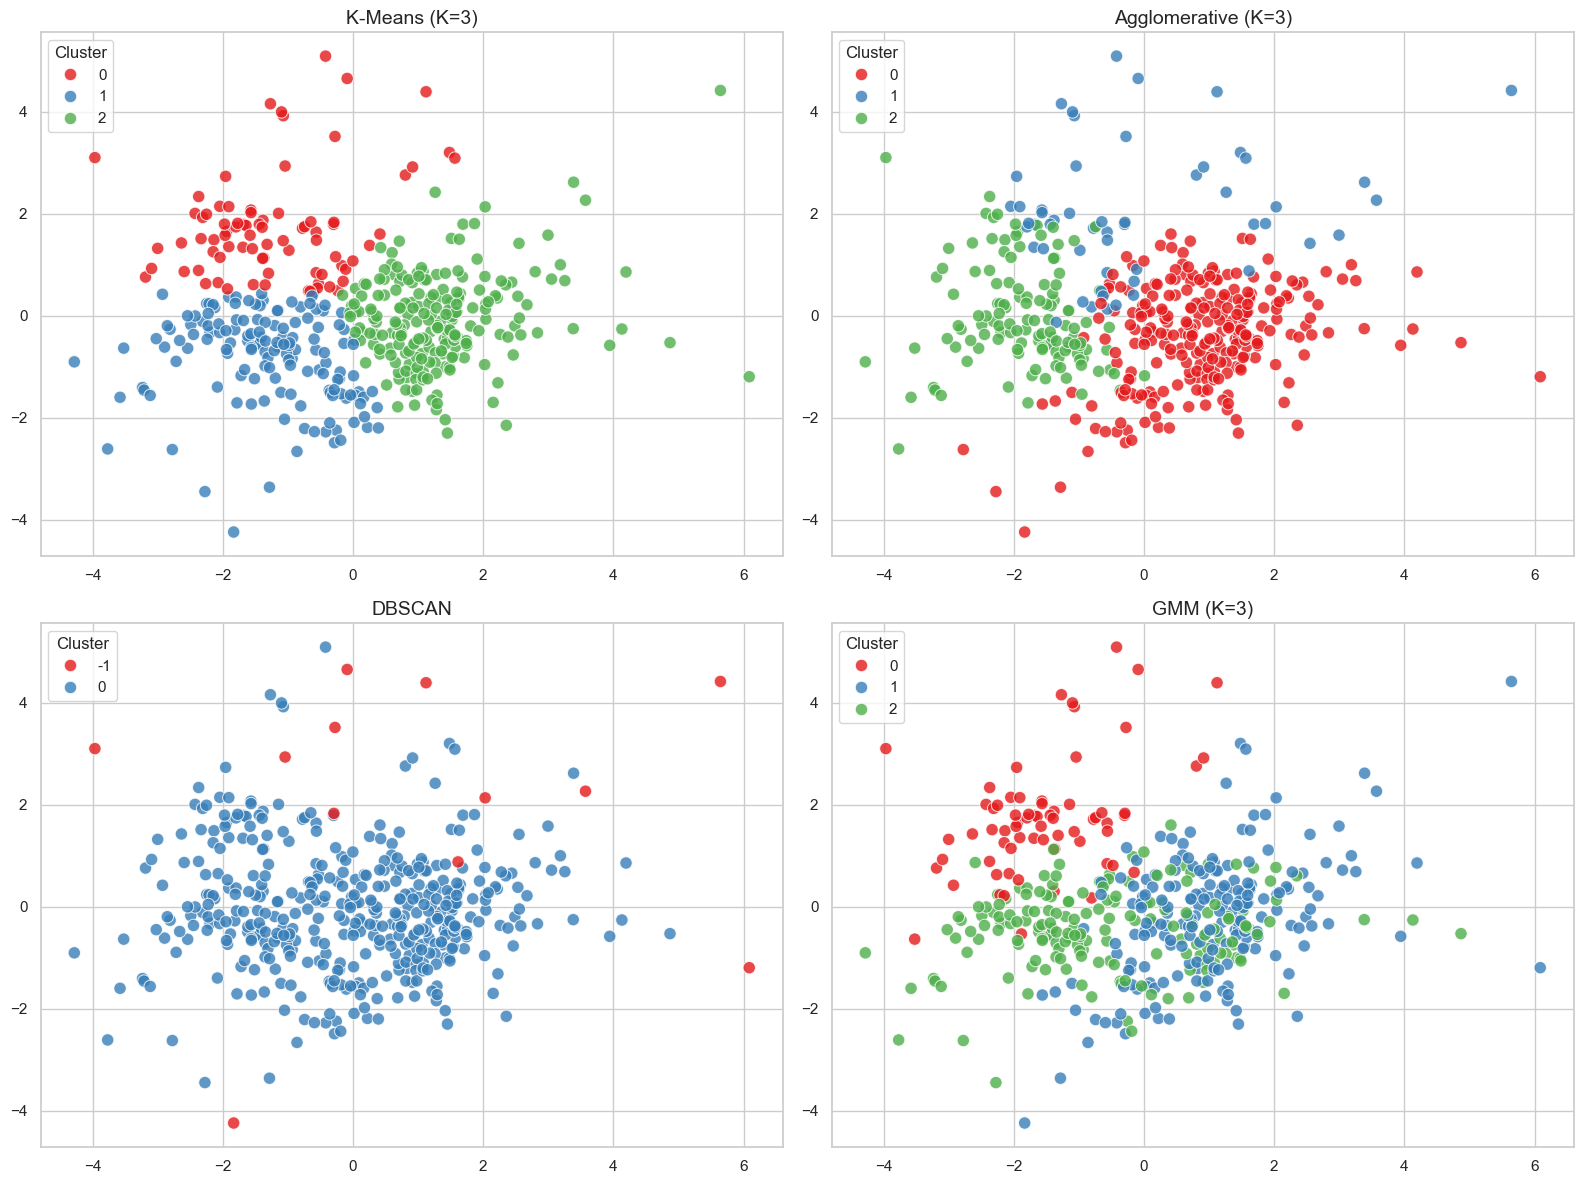

In [15]:
# Final Comparison of Algorithms
# We will mathematically and visually compare how all 4 algorithms segmented our customers.
from sklearn.metrics import silhouette_score
import seaborn as sns

# Compute the Silhouette Score for each model.
# Remember: Silhouette Score measures how well-separated and distinct the clusters are. (Closer to 1 is better).
scores = {}

# Calculate scores for the standard models
for col in ['Cluster', 'Cluster_Agg', 'Cluster_GMM']:
    scores[col] = silhouette_score(df_scaled, df[col])

# For DBSCAN, the calculation is tricky because we must remove the 'noise' points (-1) before scoring.
if len(set(df['Cluster_DBSCAN'])) > 2 or (len(set(df['Cluster_DBSCAN'])) == 2 and -1 not in df['Cluster_DBSCAN'].values):
    # Create a mask to filter out all the noise points (-1)
    mask = df['Cluster_DBSCAN'] != -1
    # Only calculate the score on the core clusters
    if len(set(df['Cluster_DBSCAN'][mask])) > 1:
        scores['Cluster_DBSCAN'] = silhouette_score(df_scaled[mask], df['Cluster_DBSCAN'][mask])

print("--- Silhouette Scores (Mathematical Distinctness) ---")
for model, score in scores.items():
    print(f"{model}: {score:.4f}")

# --- Plotting the Visual Comparison ---
# We use the same PCA 2D smashed view we created earlier, but now plot 4 separate graphs side-by-side.
# This lets us literally "see" how each algorithm decided to chop up the customer base.
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

cluster_columns = ['Cluster', 'Cluster_Agg', 'Cluster_DBSCAN', 'Cluster_GMM']
titles = ['K-Means (K=3)', 'Agglomerative (K=3)', 'DBSCAN', 'GMM (K=3)']

for i, col in enumerate(cluster_columns):
    # Plot the scatter plot for the specific algorithm
    sns.scatterplot(x=reduced_data[:,0], y=reduced_data[:,1], hue=df[col], palette='Set1', s=80, alpha=0.8, ax=axes[i])
    axes[i].set_title(titles[i], fontsize=14)
    axes[i].legend(title='Cluster', loc='best')

# Clean up spacing and display
plt.tight_layout()
plt.show()